In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('car_price_prediction_.csv')
print("Основная информация")
print(f"Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\nПервые 5 строк:")
print(df.head())
print("\nИнформация о типах данных:")
print(df.info())
print("\nОсновные статистики числовых признаков:")
print(df.describe())

Основная информация
Размер датасета: 2500 строк, 10 столбцов

Первые 5 строк:
   Car ID  Brand  Year  Engine Size Fuel Type Transmission  Mileage Condition  \
0       1  Tesla  2016          2.3    Petrol       Manual   114832       New   
1       2    BMW  2018          4.4  Electric       Manual   143190      Used   
2       3   Audi  2013          4.5  Electric       Manual   181601       New   
3       4  Tesla  2011          4.1    Diesel    Automatic    68682       New   
4       5   Ford  2009          2.6    Diesel       Manual   223009  Like New   

      Price     Model  
0  26613.92   Model X  
1  14679.61  5 Series  
2  44402.61        A4  
3  86374.33   Model Y  
4  73577.10   Mustang  

Информация о типах данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Car ID        2500 non-null   int64  
 1   Brand         2500 non

In [6]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [8]:
# Проверка пропусков
missing_data = df.isnull().sum()
print("Пропущенные значения:")
for col, count in missing_data.items():
    if count > 0:
        print(f"{col}: {count} пропусков ({count/len(df)*100:.2f}%)")

# Проверка дубликатов
duplicates = df.duplicated().sum()
print(f"\nКол-во полных дубликатов строк: {duplicates}")

Пропущенные значения:

Кол-во полных дубликатов строк: 0


In [11]:
# Анализ столбцов
for column in df.columns:
    if df[column].dtype == 'object':
        unique = df[column].nunique()
        print(f"{column}: {unique} уникальных значений")
        print(f"  Значения: {df[column].unique()}")

Brand: 7 уникальных значений
  Значения: ['Tesla' 'BMW' 'Audi' 'Ford' 'Honda' 'Mercedes' 'Toyota']
Fuel Type: 4 уникальных значений
  Значения: ['Petrol' 'Electric' 'Diesel' 'Hybrid']
Transmission: 2 уникальных значений
  Значения: ['Manual' 'Automatic']
Condition: 3 уникальных значений
  Значения: ['New' 'Used' 'Like New']
Model: 28 уникальных значений
  Значения: ['Model X' '5 Series' 'A4' 'Model Y' 'Mustang' 'Q7' 'Q5' 'Civic'
 'Explorer' 'Model 3' 'Fiesta' 'X3' 'GLA' 'A3' 'X5' 'C-Class' 'E-Class'
 'CR-V' 'Camry' 'Accord' 'GLC' 'Corolla' 'Fit' 'Model S' 'Prius'
 '3 Series' 'RAV4' 'Focus']


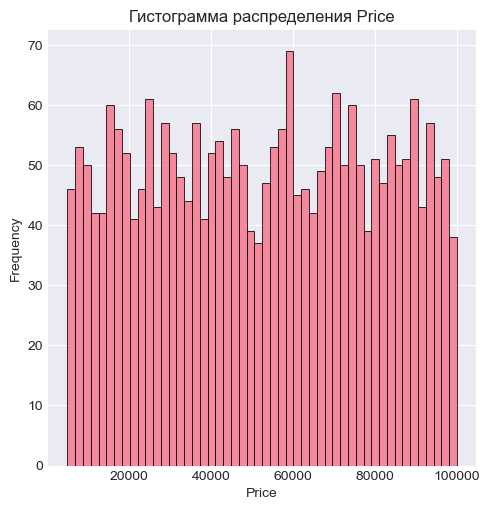

In [64]:
# Гистограмма
sns.displot(df['Price'], bins=50, edgecolor='black', alpha=0.8)
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.title('Гистограмма распределения Price')
plt.show()

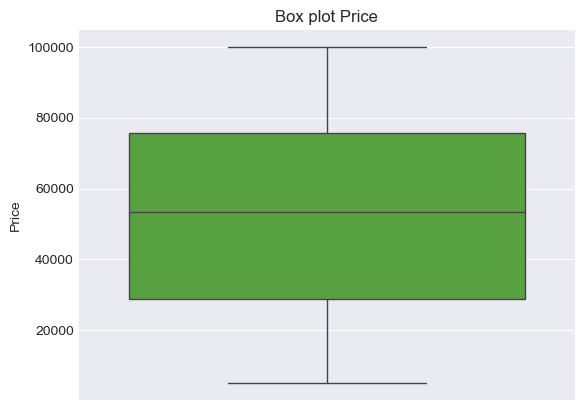

In [61]:
sns.boxplot(df['Price'])
plt.ylabel('Price')
plt.title('Box plot Price')
plt.show()

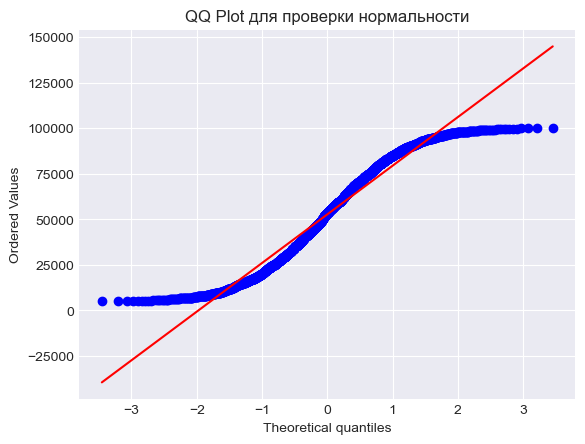

In [50]:
from scipy import stats
stats.probplot(df['Price'], dist="norm", plot=plt)
plt.title('QQ Plot для проверки нормальности')
plt.show()

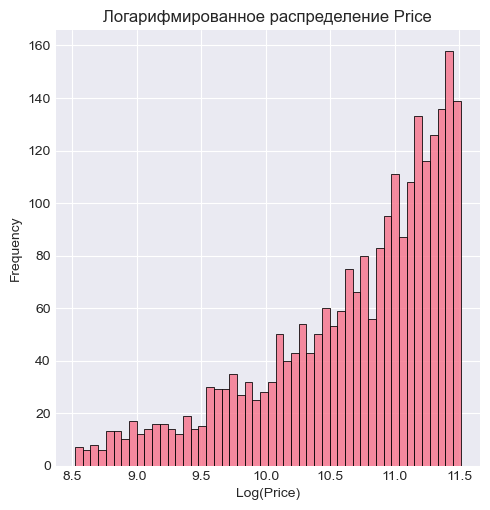

In [58]:
if df['Price'].min() > 0:
    log_price = np.log1p(df['Price'])
    sns.displot(log_price, bins=50, edgecolor='black', alpha=0.8)
    plt.xlabel('Log(Price)')
    plt.ylabel('Frequency')
    plt.title('Логарифмированное распределение Price')
else:
    plt.text(0.5, 0.5, 'Невозможно логарифмировать\n(отрицательные значения)', 
                   ha='center', va='center')
    plt.title('Логарифмированное распределение Price')

plt.show()

In [63]:
# Статистика Price
print(f"Среднее: ${df['Price'].mean():.2f}")
print(f"Медиана: ${df['Price'].median():.2f}")
print(f"Стандартное отклонение: ${df['Price'].std():.2f}")
print(f"Минимум: ${df['Price'].min():.2f}")
print(f"Максимум: ${df['Price'].max():.2f}")
print(f"Коэффициент вариации: {(df['Price'].std()/df['Price'].mean()*100):.2f}%")
print(f"Асимметрия: {df['Price'].skew():.4f}")
print(f"Эксцесс: {df['Price'].kurtosis():.4f}")

Среднее: $52638.02
Медиана: $53485.24
Стандартное отклонение: $27295.83
Минимум: $5011.27
Максимум: $99982.59
Коэффициент вариации: 51.86%
Асимметрия: -0.0145
Эксцесс: -1.2078


In [69]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Car ID' in numeric_cols:
    numeric_cols.remove('Car ID')
if 'Price' in numeric_cols:
    numeric_cols.remove('Price')

print(f"Числовые признаки: {numeric_cols}")

Числовые признаки: ['Year', 'Engine Size', 'Mileage']


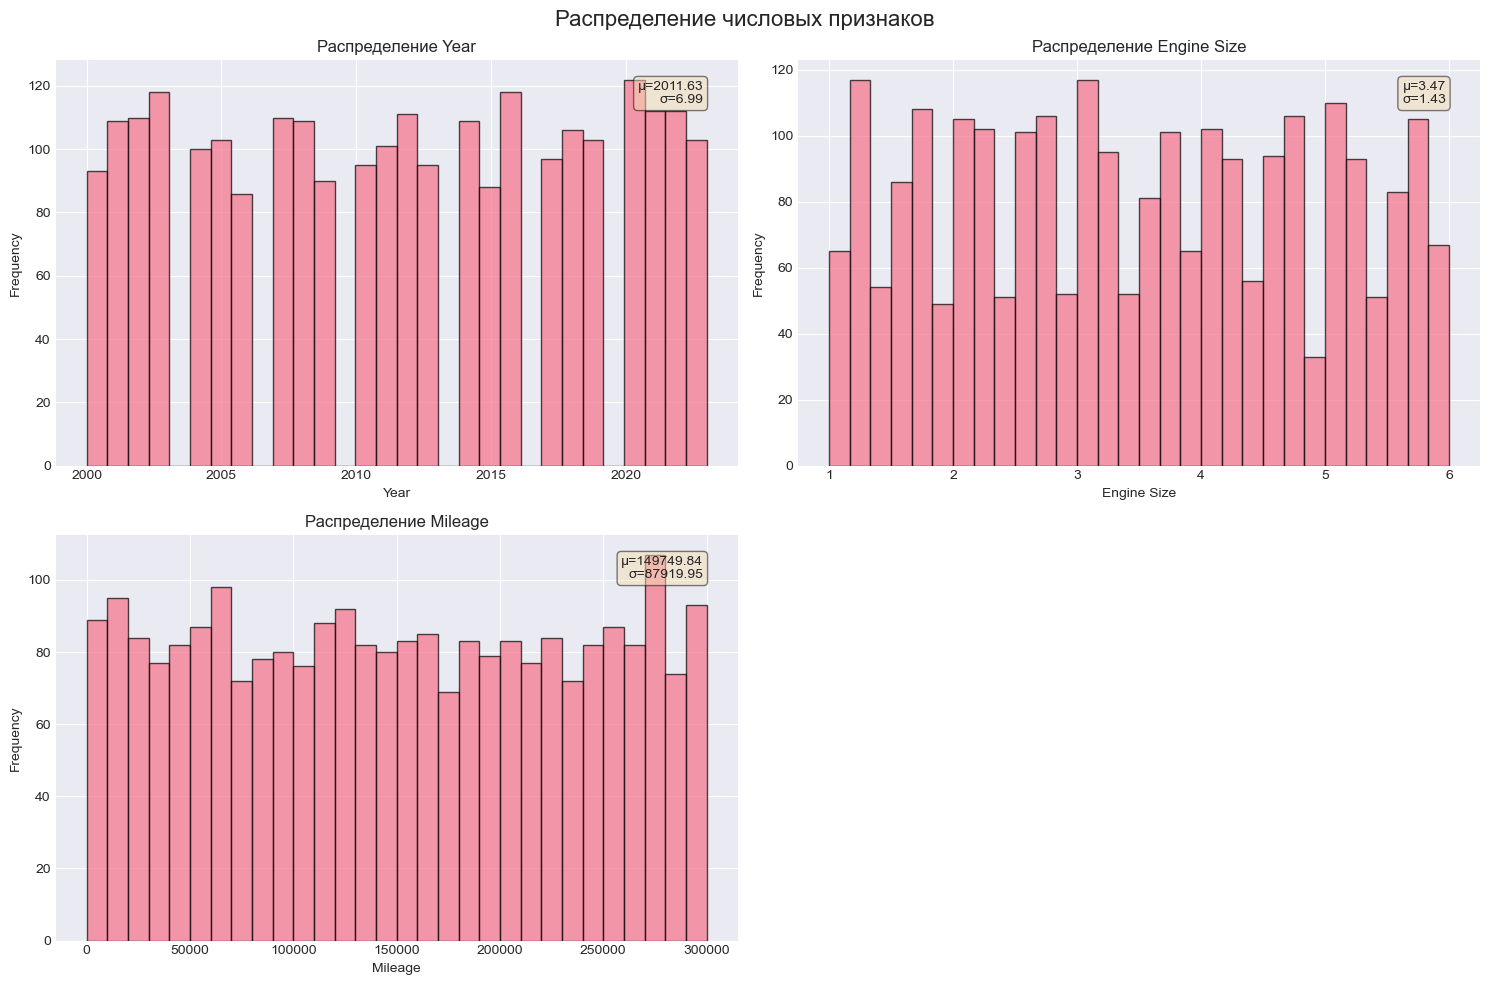

In [75]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Распределение числовых признаков', fontsize=16)

for idx, col in enumerate(numeric_cols[:4]):
    ax = axes[idx//2, idx%2]
    ax.hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    ax.set_xlabel(col)
    ax.set_ylabel('Frequency')
    ax.set_title(f'Распределение {col}')
    
    # Добавляем статистики
    stats_text = f"μ={df[col].mean():.2f}\nσ={df[col].std():.2f}"
    ax.text(0.95, 0.95, stats_text, transform=ax.transAxes, 
            fontsize=10, verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

if len(numeric_cols) < 4:
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

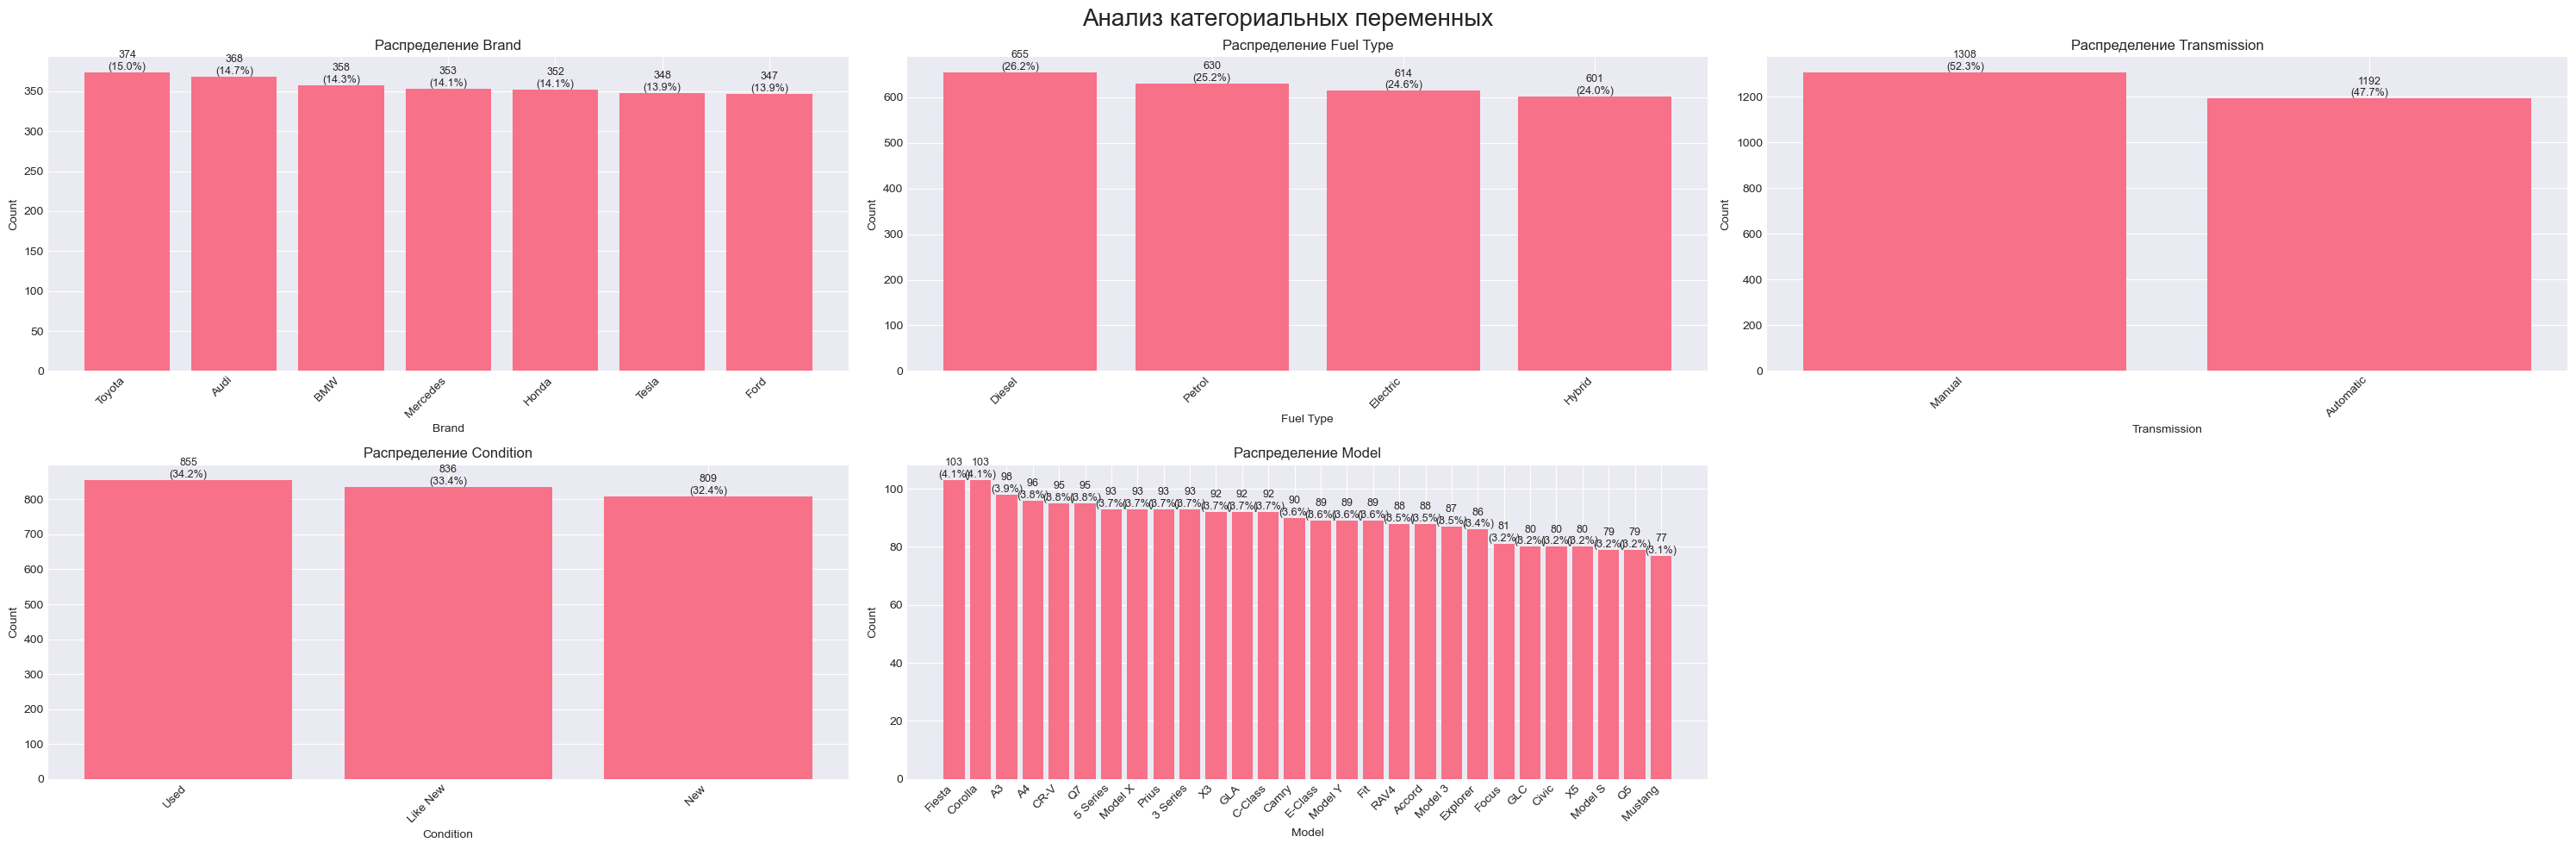

In [84]:
categorical_cols = ['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model']
fig, axes = plt.subplots(2, 3, figsize=(30, 10))
fig.suptitle('Анализ категориальных переменных', fontsize=20)

for idx, col in enumerate(categorical_cols):
    ax = axes[idx//3, idx%3]
    
    # Подсчет значений
    value_counts = df[col].value_counts()
    
    # Столбчатая диаграмма
    bars = ax.bar(range(len(value_counts)), value_counts.values)
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.set_title(f'Распределение {col}')
    ax.set_xticks(range(len(value_counts)))
    ax.set_xticklabels(value_counts.index, rotation=45, ha='right')
    
    # Добавляем значения на столбцы
    for bar, count in zip(bars, value_counts.values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{count}\n({count/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)

# Удаляем пустой subplot если нужно
if len(categorical_cols) < 6:
    axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

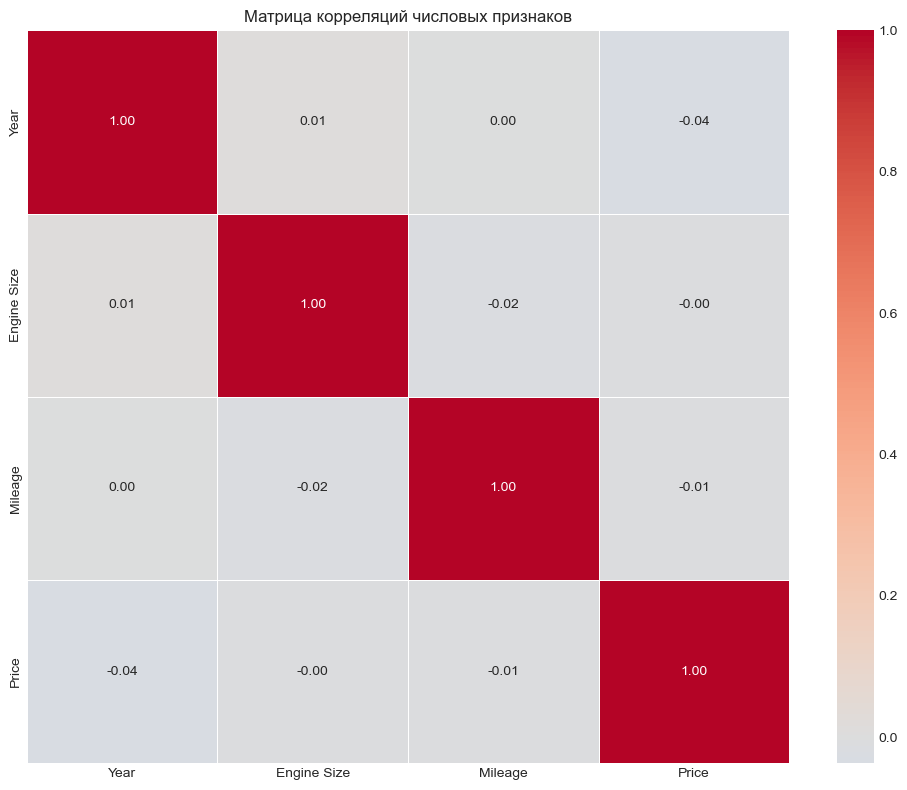

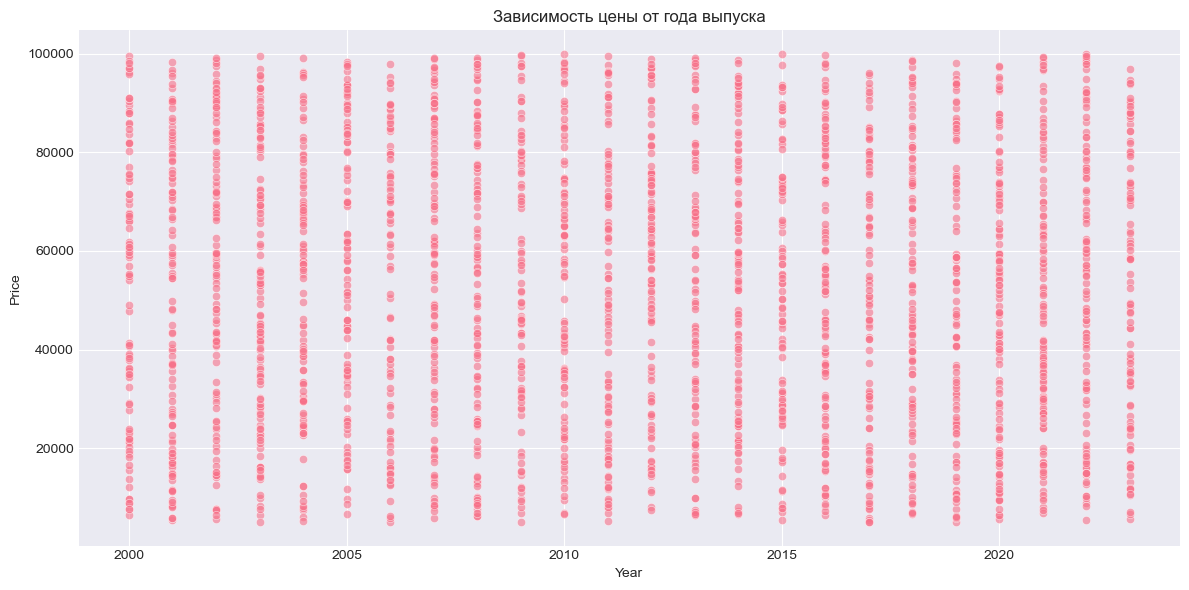

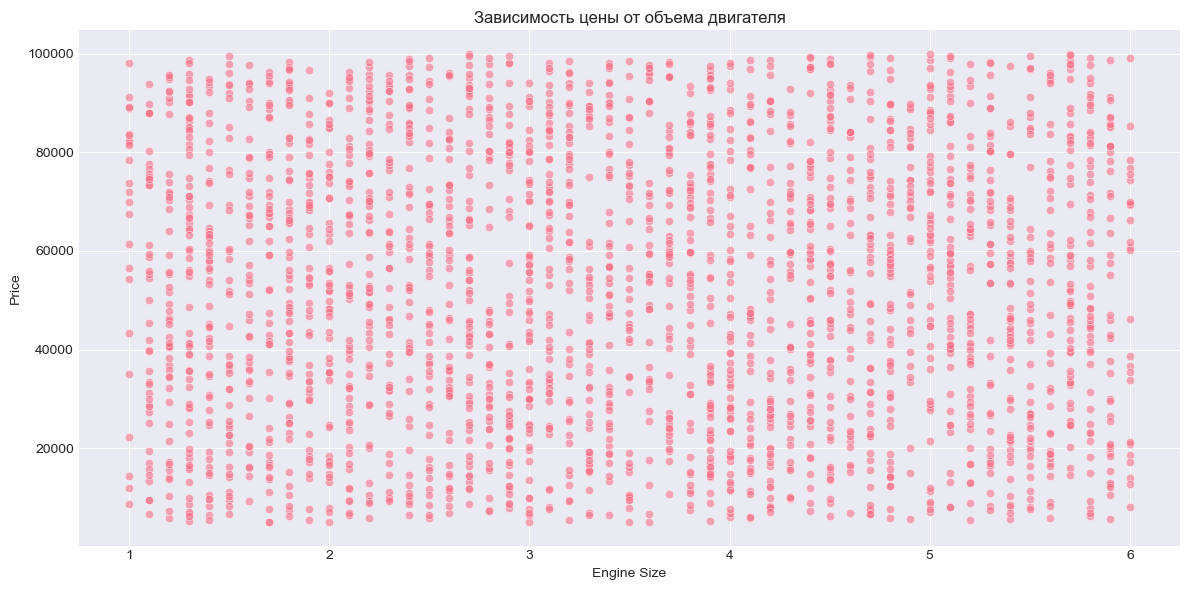

In [85]:
# Матрица корреляций для числовых признаков
numeric_df = df.select_dtypes(include=[np.number])
if 'Car ID' in numeric_df.columns:
    numeric_df = numeric_df.drop('Car ID', axis=1)

plt.figure(figsize=(10, 8))
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', 
            center=0, linewidths=0.5, fmt='.2f')
plt.title('Матрица корреляций числовых признаков')
plt.tight_layout()
plt.show()

# Анализ связи Year и Price
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Year', y='Price', alpha=0.6)
plt.title('Зависимость цены от года выпуска')
plt.xlabel('Year')
plt.ylabel('Price')
plt.tight_layout()
plt.show()

# Анализ связи Engine Size и Price
plt.figure(figsize=(12, 6))
sns.scatterplot(data=df, x='Engine Size', y='Price', alpha=0.6)
plt.title('Зависимость цены от объема двигателя')
plt.xlabel('Engine Size')
plt.ylabel('Price')
plt.tight_layout()
plt.show()


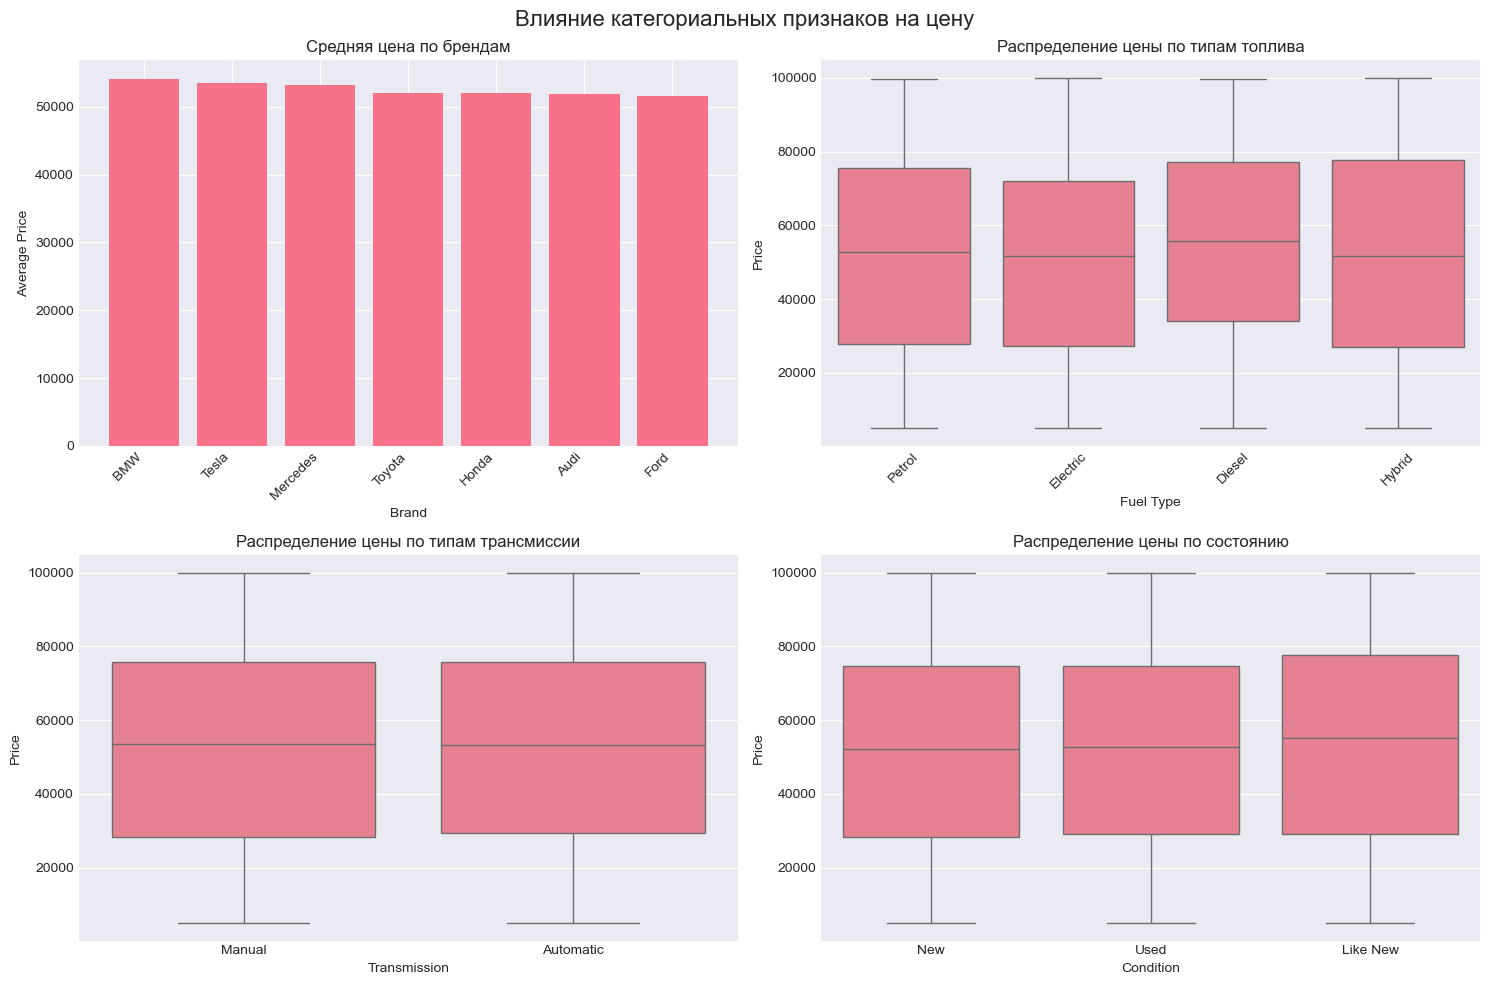

In [86]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Влияние категориальных признаков на цену', fontsize=16)

# Brand vs Price
brand_price = df.groupby('Brand')['Price'].agg(['mean', 'median', 'std', 'count']).sort_values('mean', ascending=False)
axes[0,0].bar(range(len(brand_price)), brand_price['mean'])
axes[0,0].set_xlabel('Brand')
axes[0,0].set_ylabel('Average Price')
axes[0,0].set_title('Средняя цена по брендам')
axes[0,0].set_xticks(range(len(brand_price)))
axes[0,0].set_xticklabels(brand_price.index, rotation=45, ha='right')

# Fuel Type vs Price
sns.boxplot(data=df, x='Fuel Type', y='Price', ax=axes[0,1])
axes[0,1].set_title('Распределение цены по типам топлива')
axes[0,1].set_xticklabels(axes[0,1].get_xticklabels(), rotation=45)

# Transmission vs Price
sns.boxplot(data=df, x='Transmission', y='Price', ax=axes[1,0])
axes[1,0].set_title('Распределение цены по типам трансмиссии')

# Condition vs Price
sns.boxplot(data=df, x='Condition', y='Price', ax=axes[1,1])
axes[1,1].set_title('Распределение цены по состоянию')

plt.tight_layout()
plt.show()

Выбросы в Price (метод IQR):
  Нижняя граница: $-41486.59
  Верхняя граница: $146233.60
  Количество выбросов: 0 (0.00%)


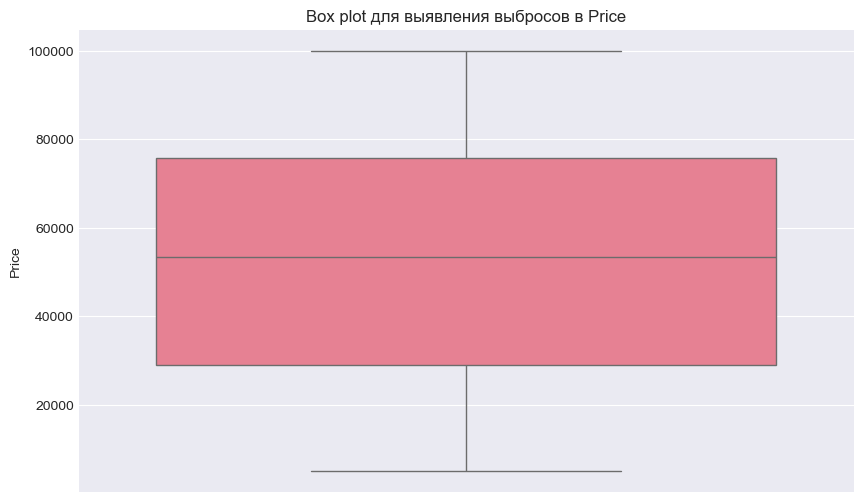

In [136]:
# Анализ выбросов
# Метод межквартильного размаха IQR для Price
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Price'] < lower_bound) | (df['Price'] > upper_bound)]
print(f"Выбросы в Price (метод IQR):")
print(f"  Нижняя граница: ${lower_bound:.2f}")
print(f"  Верхняя граница: ${upper_bound:.2f}")
print(f"  Количество выбросов: {len(outliers)} ({len(outliers)/len(df)*100:.2f}%)")

# Визуализация выбросов
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y='Price')
plt.title('Box plot для выявления выбросов в Price')
plt.ylabel('Price')
plt.show()


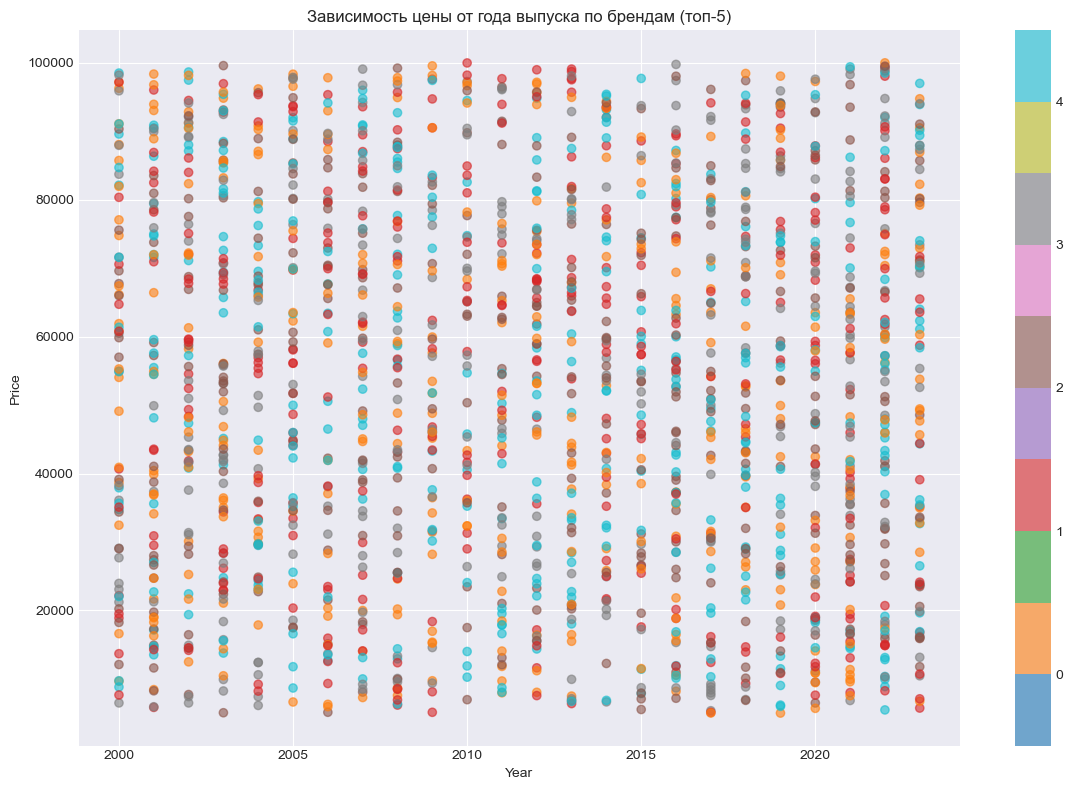

In [90]:
# Многомерный анализ
top_brands = df['Brand'].value_counts().head(5).index.tolist()
df_top_brands = df[df['Brand'].isin(top_brands)]

plt.figure(figsize=(12, 8))
scatter = plt.scatter(df_top_brands['Year'], df_top_brands['Price'], 
                      c=pd.Categorical(df_top_brands['Brand']).codes, 
                      alpha=0.6, cmap='tab10')
plt.colorbar(scatter, ticks=range(len(top_brands)))
plt.clim(-0.5, len(top_brands)-0.5)
plt.title('Зависимость цены от года выпуска по брендам (топ-5)')
plt.xlabel('Year')
plt.ylabel('Price')
plt.tight_layout()
plt.show()


In [191]:
!pip install catboost
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from catboost import CatBoostRegressor

In [192]:
# Модель машинного обучения catboost для предсказания цены 
# Подготовка данных
# Создаем копию данных для ML
df_ml = df.copy()

In [193]:
if 'Car ID' in df_ml.columns:
    df_ml = df_ml.drop('Car ID', axis=1)
print(df_ml.head())

   Brand  Year  Engine Size Fuel Type Transmission  Mileage Condition  \
0  Tesla  2016          2.3    Petrol       Manual   114832       New   
1    BMW  2018          4.4  Electric       Manual   143190      Used   
2   Audi  2013          4.5  Electric       Manual   181601       New   
3  Tesla  2011          4.1    Diesel    Automatic    68682       New   
4   Ford  2009          2.6    Diesel       Manual   223009  Like New   

      Price     Model  
0  26613.92   Model X  
1  14679.61  5 Series  
2  44402.61        A4  
3  86374.33   Model Y  
4  73577.10   Mustang  


In [194]:
label_encoders = {}
for column in ['Brand', 'Fuel Type', 'Transmission', 'Condition', 'Model']:
    if column in df_ml.columns:
        le = LabelEncoder()
        df_ml[column] = le.fit_transform(df_ml[column].astype(str))
        label_encoders[column] = le
        print(f"Закодирован столбец: {column}, уникальных значений: {len(le.classes_)}")
print(df_ml.head())

Закодирован столбец: Brand, уникальных значений: 7
Закодирован столбец: Fuel Type, уникальных значений: 4
Закодирован столбец: Transmission, уникальных значений: 2
Закодирован столбец: Condition, уникальных значений: 3
Закодирован столбец: Model, уникальных значений: 28
   Brand  Year  Engine Size  Fuel Type  Transmission  Mileage  Condition  \
0      5  2016          2.3          3             1   114832          1   
1      1  2018          4.4          1             1   143190          2   
2      0  2013          4.5          1             1   181601          1   
3      5  2011          4.1          0             0    68682          1   
4      2  2009          2.6          0             1   223009          0   

      Price  Model  
0  26613.92     19  
1  14679.61      1  
2  44402.61      3  
3  86374.33     20  
4  73577.10     21  


In [195]:
# Разделяем на признаки и целевую переменную
X = df_ml.drop('Price', axis=1)
y = df_ml['Price']
# Разделяем на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y,
    test_size=0.2,
    random_state=42
)
print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


Размер обучающей выборки: (2000, 8)
Размер тестовой выборки: (500, 8)


In [196]:
# Инициализация и обучение модели CatBoost
catboost_model = CatBoostRegressor(
    iterations=1000, # кол-во деревьев
    learning_rate=0.05, # скорость обучения
    depth=6, # глубина дерева
    loss_function='RMSE',
    verbose=100, # вывод итераций
    random_state=42
)
print("Обучение модели CatBoost")
catboost_model.fit(X_train, y_train, eval_set=(X_test, y_test))

Обучение модели CatBoost
0:	learn: 27185.0389457	test: 27529.7121163	best: 27529.7121163 (0)	total: 5.44ms	remaining: 5.44s
100:	learn: 24856.6451223	test: 27831.6487604	best: 27524.2824306 (2)	total: 49ms	remaining: 437ms
200:	learn: 23038.7704902	test: 28082.1504930	best: 27524.2824306 (2)	total: 88.3ms	remaining: 351ms
300:	learn: 21497.2651554	test: 28312.6439460	best: 27524.2824306 (2)	total: 131ms	remaining: 304ms
400:	learn: 20208.5324009	test: 28567.2861443	best: 27524.2824306 (2)	total: 173ms	remaining: 259ms
500:	learn: 19175.9182781	test: 28824.3429702	best: 27524.2824306 (2)	total: 214ms	remaining: 213ms
600:	learn: 18185.2595615	test: 29048.5104036	best: 27524.2824306 (2)	total: 256ms	remaining: 170ms
700:	learn: 17291.6040441	test: 29229.9561631	best: 27524.2824306 (2)	total: 299ms	remaining: 128ms
800:	learn: 16550.9757794	test: 29357.6470785	best: 27524.2824306 (2)	total: 341ms	remaining: 84.6ms
900:	learn: 15804.6423232	test: 29571.5279781	best: 27524.2824306 (2)	total

In [197]:
# Предикты
y_train_pred = catboost_model.predict(X_train)
y_test_pred = catboost_model.predict(X_test)

In [198]:
# Оценка модели
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)
# Результаты
print(f"Обучающая выборка:")
print(f"  RMSE: ${train_rmse:.2f}")
print(f"  MAE: ${train_mae:.2f}")
print(f"  R² Score: {train_r2:.4f}")
print(f"\nТестовая выборка:")
print(f"  RMSE: ${test_rmse:.2f}")
print(f"  MAE: ${test_mae:.2f}")
print(f"  R² Score: {test_r2:.4f}")


Обучающая выборка:
  RMSE: $27099.89
  MAE: $23571.05
  R² Score: 0.0095

Тестовая выборка:
  RMSE: $27524.28
  MAE: $23770.42
  R² Score: -0.0000


In [199]:
print("\nКросс-валидация ")
cv_scores = cross_val_score(catboost_model, X, y, cv=5, scoring='r2')
print(f"R² кросс-валидация: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")



Кросс-валидация 
0:	learn: 27050.8049598	total: 1.3ms	remaining: 1.3s
100:	learn: 24818.9013009	total: 54.7ms	remaining: 487ms
200:	learn: 23150.1779711	total: 98.9ms	remaining: 393ms
300:	learn: 21673.5891925	total: 139ms	remaining: 322ms
400:	learn: 20414.6152361	total: 179ms	remaining: 267ms
500:	learn: 19253.7089831	total: 221ms	remaining: 220ms
600:	learn: 18280.7823756	total: 260ms	remaining: 173ms
700:	learn: 17372.7209827	total: 300ms	remaining: 128ms
800:	learn: 16576.9708429	total: 340ms	remaining: 84.4ms
900:	learn: 15842.6793100	total: 379ms	remaining: 41.6ms
999:	learn: 15186.9983075	total: 418ms	remaining: 0us
0:	learn: 27492.3492149	total: 501us	remaining: 501ms
100:	learn: 25110.7476790	total: 47.4ms	remaining: 422ms
200:	learn: 23396.7148313	total: 85.9ms	remaining: 342ms
300:	learn: 21883.0896756	total: 123ms	remaining: 285ms
400:	learn: 20612.9193483	total: 160ms	remaining: 238ms
500:	learn: 19511.9287719	total: 198ms	remaining: 198ms
600:	learn: 18566.0224321	total

In [200]:
feature_importance = catboost_model.get_feature_importance()
feature_names = X.columns
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("Топ 10 важнейших признаков:")
print(importance_df.head(10).to_string(index=False))

Топ 10 важнейших признаков:
     Feature  Importance
   Fuel Type   22.259016
        Year   17.612635
     Mileage   14.500904
       Model   14.477278
Transmission   12.771769
 Engine Size    6.991429
       Brand    6.278729
   Condition    5.108240


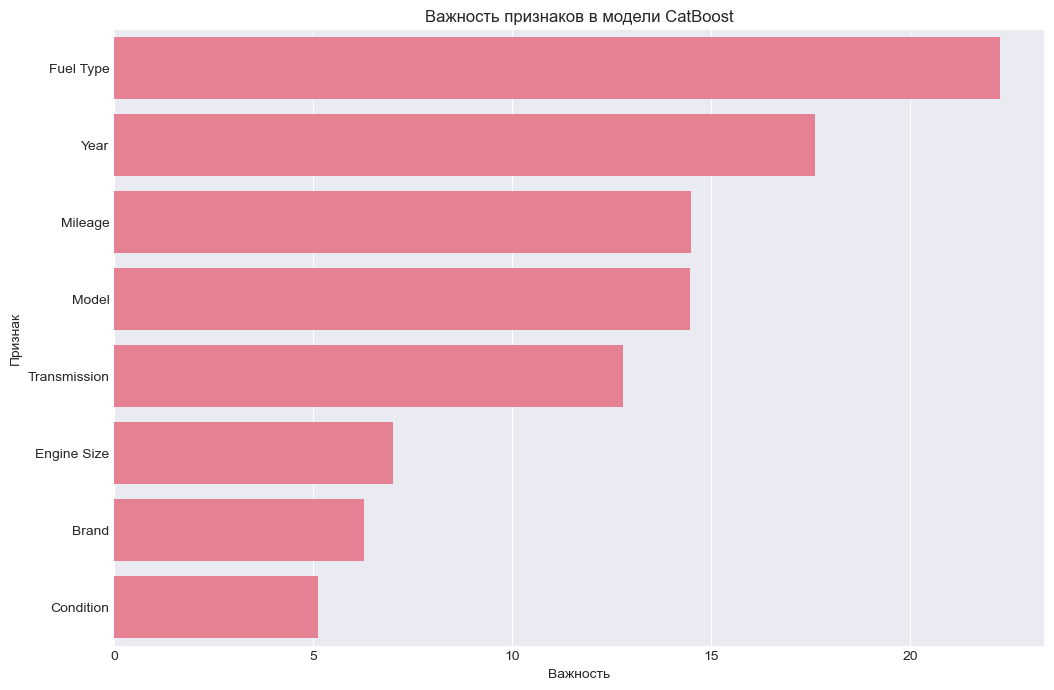

In [201]:
# Визуализация этих признаков
plt.figure(figsize=(12, 8))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature')
plt.title('Важность признаков в модели CatBoost')
plt.xlabel('Важность')
plt.ylabel('Признак')
plt.show()

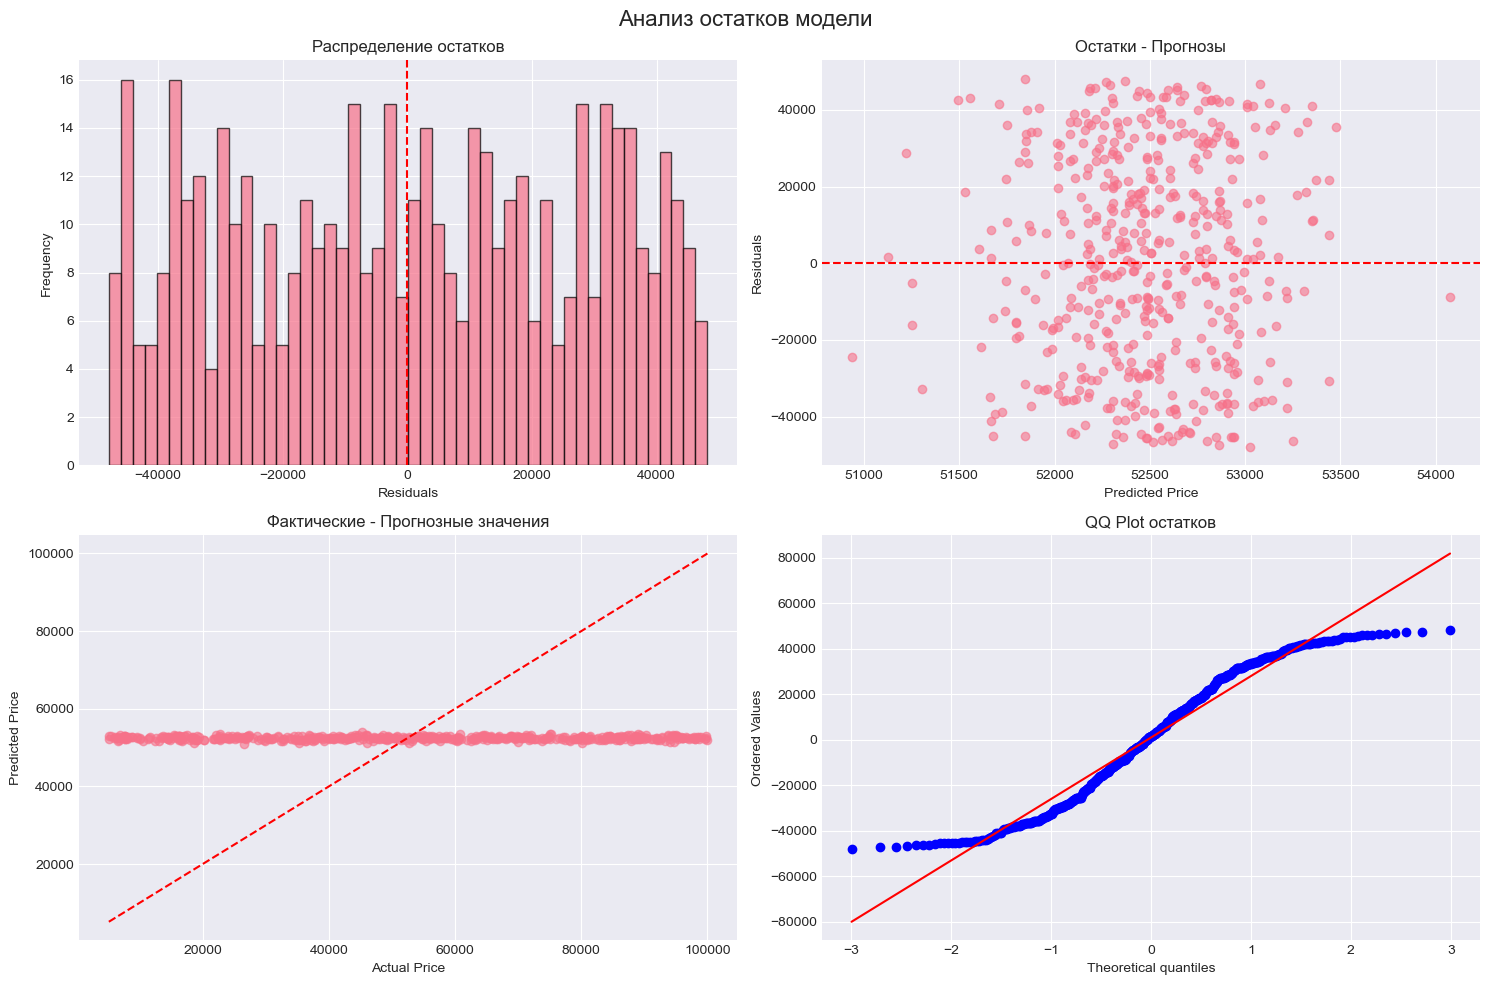

In [202]:
# Анализ ошибок
# Остатки 
residuals = y_test - y_test_pred

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Анализ остатков модели', fontsize=16)

# Распределение остатков
axes[0,0].hist(residuals, bins=50, edgecolor='black', alpha=0.7)
axes[0,0].axvline(x=0, color='r', linestyle='--')
axes[0,0].set_xlabel('Residuals')
axes[0,0].set_ylabel('Frequency')
axes[0,0].set_title('Распределение остатков')

# Остатки - Прогнозы
axes[0,1].scatter(y_test_pred, residuals, alpha=0.6)
axes[0,1].axhline(y=0, color='r', linestyle='--')
axes[0,1].set_xlabel('Predicted Price')
axes[0,1].set_ylabel('Residuals')
axes[0,1].set_title('Остатки - Прогнозы')

# Фактические - Прогнозные значения
axes[1,0].scatter(y_test, y_test_pred, alpha=0.6)
axes[1,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
axes[1,0].set_xlabel('Actual Price')
axes[1,0].set_ylabel('Predicted Price')
axes[1,0].set_title('Фактические - Прогнозные значения')

# QQ plot остатков
stats.probplot(residuals, dist="norm", plot=axes[1,1])
axes[1,1].set_title('QQ Plot остатков')

plt.tight_layout()
plt.show()

In [203]:
# Статистика остатков
print("Статистика остатков:")
print(f"Среднее остатков: {residuals.mean():.2f}")
print(f"Стандартное отклонение остатков: {residuals.std():.2f}")
print(f"Максимальная положительная ошибка: {residuals.max():.2f}")
print(f"Максимальная отрицательная ошибка: {residuals.min():.2f}")
print(f"Процент ошибок в пределах $5000: {(abs(residuals) <= 5000).sum()/len(residuals)*100:.2f}%")
print(f"Процент ошибок в пределах $10000: {(abs(residuals) <= 10000).sum()/len(residuals)*100:.2f}%")

Статистика остатков:
Среднее остатков: 862.63
Стандартное отклонение остатков: 27538.31
Максимальная положительная ошибка: 48139.79
Максимальная отрицательная ошибка: -47902.13
Процент ошибок в пределах $5000: 11.40%
Процент ошибок в пределах $10000: 21.20%


In [187]:
print(f"   - Качество модели (R²): {test_r2:.4f}")
print(f"   - Средняя ошибка (MAE): ${test_mae:.2f}")
print(f"   - Среднеквадратичная ошибка (RMSE): ${test_rmse:.2f}")

   - Качество модели (R²): 0.0027
   - Средняя ошибка (MAE): $23685.60
   - Среднеквадратичная ошибка (RMSE): $27486.26


In [188]:
print(f"   - Средняя цена автомобиля: ${df['Price'].mean():.2f}")
print(f"   - Медианная цена: ${df['Price'].median():.2f}")
print(f"   - Стандартное отклонение: ${df['Price'].std():.2f}")
print(f"   - Разброс цен: от ${df['Price'].min():.2f} до ${df['Price'].max():.2f}")

   - Средняя цена автомобиля: $52638.02
   - Медианная цена: $53485.24
   - Стандартное отклонение: $27295.83
   - Разброс цен: от $5011.27 до $99982.59
